In [12]:
%reload_ext autoreload
%autoreload 2

In [13]:
import pandas as pd
new_df =  pd.read_csv("/rhome/sawale/indus_traning/sentense_transformers/data/sde_new_dump/processed_prod_sde_index_2025-10-24.csv.zip", compression='zip')

# drop rows with na url1
new_df = new_df.dropna(subset=["url1"])
# drop duplicates based on url1
new_df = new_df.drop_duplicates(subset=["url1"])
new_df.shape


new_df.head()

/tmp/ipykernel_3591441/3705640127.py:2: DtypeWarning: Columns (3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,25,26,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,54,55,57,58,59,60,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,83,86) have mixed types. Specify dtype option on import or set low_memory=False.
  new_df =  pd.read_csv("/rhome/sawale/indus_traning/sentense_transformers/data/sde_new_dump/processed_prod_sde_index_2025-10-24.csv.zip", compression='zip')


,id,version,sourcebool1,sourcestr1,sourcestr2,sourcestr3,sourcestr4,url2,sourcestr5,sourcestr6,...,sourcestr58,sourcedouble1,sourcestr59,authors,sourcebool2,sourcestr60,sourcestr61,collection,text,sourcebool3
0,/SDE/activate_aerosol_cloud_meteorology_intera...,e200357360b8befa5b760d481e5181d2,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,False,NaN,NaN,/SDE/activate_aerosol_cloud_meteorology_intera...,ACTIVATE: Data - NASA Langley Research Center ...,False
1,/SDE/activate_aerosol_cloud_meteorology_intera...,f83b58206e2505a683acec4c2de59a63,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,False,NaN,NaN,/SDE/activate_aerosol_cloud_meteorology_intera...,ACTIVATE: Home - NASA Langley Research Center ...,False
2,/SDE/activate_aerosol_cloud_meteorology_intera...,1c15a12d5edbcd8f49c0dcc43f9c1b77,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,False,NaN,NaN,/SDE/activate_aerosol_cloud_meteorology_intera...,ACTIVATE: Media - NASA Langley Research Center...,False
3,/SDE/activate_aerosol_cloud_meteorology_intera...,a25f087a5eb2784d4b898a7346bbcaf9,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,False,NaN,NaN,/SDE/activate_aerosol_cloud_meteorology_intera...,ACTIVATE: Instruments - NASA Langley Research ...,False
4,/SDE/activate_aerosol_cloud_meteorology_intera...,45c4b1905700501c6da7e5996a8d79cc,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,False,NaN,NaN,/SDE/activate_aerosol_cloud_meteorology_intera...,ACTIVATE: Education - NASA Langley Research Ce...,False


In [14]:
new_df.shape

(538073, 90)

In [15]:
old_df = pd.read_csv("/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/data/cleaned_production_dump.csv")

# drop rows with na url1
old_df = old_df.dropna(subset=["url1"])
# drop duplicates based on url1
old_df = old_df.drop_duplicates(subset=["url1"])

old_df.head()

,id,url1,title,collection,treepath,sourcestr56,text,sourcebool3
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Data,ACTIVATE: Data - NASA Langley Research Center ...,False
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Home - NASA Langley Research Center ...,False
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Media - NASA Langley Research Center...,False
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Missions and Instruments,ACTIVATE: Instruments - NASA Langley Research ...,False
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,/SDE/activate_aerosol_cloud_meteorology_intera...,/Earth Science/ACTIVATE: Aerosol Cloud Meteoro...,Documentation,ACTIVATE: Education - NASA Langley Research Ce...,False


In [16]:
old_df.shape

(470795, 8)

In [17]:
old_df["url1"].isna().sum()

np.int64(0)

In [18]:
new_collections  = set(new_df["collection"].unique()) - set(old_df["collection"].unique())

In [19]:
diff_df = new_df[new_df["collection"].isin(new_collections)]

In [22]:
diff_df.shape

(56316, 8)

In [21]:
# filter required columns
required_columns = ["id", "url1", "title", "collection", "treepath", "sourcestr56", "text", "sourcebool3" ]

diff_df = diff_df[required_columns]

# use content relevancy model 

In [25]:
from huggingface_hub import login
import os
from dotenv import load_dotenv

load_dotenv("../eval/.env")
hf_token = os.getenv("HUGGINGFACE_TOKEN")

# Login first
login(token=hf_token)

# Then load the model
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("nasa-impact/sde-content-relevancy")
model = AutoModelForSequenceClassification.from_pretrained("nasa-impact/sde-content-relevancy")

In [26]:
import torch
from tqdm import tqdm

def get_confidence_scores(texts, tokenizer, model, batch_size=32):
    """Get confidence scores for a list of texts"""
    confidence_scores = []
    
    # Process in batches for efficiency
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing texts"):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            truncation=True, 
            padding=True, 
            max_length=512
        )
        
        # Get predictions
        with torch.no_grad():
            outputs = model(**inputs)
            probabilities = torch.softmax(outputs.logits, dim=-1)
            confidences = torch.max(probabilities, dim=-1).values.tolist()
        
        confidence_scores.extend(confidences)
    
    return confidence_scores

# Get confidence scores for all texts in diff_df
print("Calculating confidence scores...")
confidence_scores = get_confidence_scores(
    diff_df['text'].fillna("").tolist(),  # Handle any NaN values
    tokenizer, 
    model, 
    batch_size=16  # Adjust based on your GPU memory
)

# Add as new column
diff_df['prob'] = confidence_scores

print(f"Added 'prob' column with confidence scores")
print(f"Score range: {min(confidence_scores):.4f} - {max(confidence_scores):.4f}")
print(f"Mean confidence: {sum(confidence_scores)/len(confidence_scores):.4f}")

# Show some examples
print("\nSample results:")
print(diff_df[['title', 'prob']].head())

Calculating confidence scores...


Processing texts:   0%|          | 0/7 [00:00<?, ?it/s]

Processing texts: 100%|██████████| 7/7 [00:09<00:00,  1.31s/it]

Added 'prob' column with confidence scores
Score range: 0.5306 - 0.9993
Mean confidence: 0.9100

Sample results:
                                                    title      prob
481478                 Solar Optical Telescope (SOT) Data  0.996071
481479                    SOT/SP LEVEL 2 Data Description  0.985070
481480            Solar Optical Telescope (SOT) Home Page  0.999320
481481  Level 2.1 (Disambiguated SOT-SP Data) - SOT Da...  0.998299
481482    Hinode-SOT Spectropolarimeter (SP) Level 1 Data  0.984753


In [27]:
diff_df

,id,url1,title,collection,treepath,sourcestr56,text,sourcebool3,prob
481478,/SDE/solar_optical_telescope_on_hinode/|https:...,https://sot.lmsal.com/Data_new.html,Solar Optical Telescope (SOT) Data,/SDE/solar_optical_telescope_on_hinode/,/Heliophysics/Solar Optical Telescope (SOT) on...,Data,SOT Data Page\n\nData Access\n\nSOT and XRT da...,False,0.996071
481479,/SDE/solar_optical_telescope_on_hinode/|https:...,https://sot.lmsal.com/data/sot/level2d/sotsp_l...,SOT/SP LEVEL 2 Data Description,/SDE/solar_optical_telescope_on_hinode/,/Heliophysics/Solar Optical Telescope (SOT) on...,Documentation,Description of Hinode SOT/SP Level2 processing...,False,0.985070
481480,/SDE/solar_optical_telescope_on_hinode/|https:...,https://sot.lmsal.com/,Solar Optical Telescope (SOT) Home Page,/SDE/solar_optical_telescope_on_hinode/,/Heliophysics/Solar Optical Telescope (SOT) on...,Missions and Instruments,SOT Home Page\n\nSolar Optical Telescope on Hi...,False,0.999320
481481,/SDE/solar_optical_telescope_on_hinode/|https:...,https://sot.lmsal.com/data/sot/sotguide/book/c...,Level 2.1 (Disambiguated SOT-SP Data) - SOT Da...,/SDE/solar_optical_telescope_on_hinode/,/Heliophysics/Solar Optical Telescope (SOT) on...,Documentation,Level 2.1 (Disambiguated SOT-SP Data) - SOT Da...,False,0.998299
481482,/SDE/solar_optical_telescope_on_hinode/|https:...,https://sot.lmsal.com/data/sot/level1d,Hinode-SOT Spectropolarimeter (SP) Level 1 Data,/SDE/solar_optical_telescope_on_hinode/,/Heliophysics/Solar Optical Telescope (SOT) on...,Data,Created by data_ops at 26-MAR-25 01:27:32 UT\n...,False,0.984753
...,...,...,...,...,...,...,...,...,...
481573,/SDE/oco_2_orbiting_carbon_observatory_2/|http...,https://ocov2.jpl.nasa.gov/oco-2-news/exciteme...,Orbiting Carbon Observatory-2: \n \...,/SDE/oco_2_orbiting_carbon_observatory_2/,/Earth Science/OCO-2: Orbiting Carbon Observat...,Documentation,Orbiting Carbon Observatory-2: Excitement Grow...,False,0.988328
481574,/SDE/the_science_gateway/|https://rbspgway.jhu...,https://rbspgway.jhuapl.edu/weather_dataproducts,SPACE WEATHER: Data Product Descriptions | Van...,/SDE/the_science_gateway/,/Planetary Science/The Science Gateway/,Documentation,You need to enable JavaScript to run this app....,False,0.822623
481575,/SDE/oco_2_orbiting_carbon_observatory_2/|http...,https://ocov2.jpl.nasa.gov/oco-2-news/fourier-...,Orbiting Carbon Observatory-2: \n \...,/SDE/oco_2_orbiting_carbon_observatory_2/,/Earth Science/OCO-2: Orbiting Carbon Observat...,Documentation,Orbiting Carbon Observatory-2: Fourier Transfo...,False,0.995610
481576,/SDE/the_science_gateway/|http://rbspgway.jhua...,http://rbspgway.jhuapl.edu/sites/default/files...,Geospace Exploration Project - ERG,/SDE/the_science_gateway/,/Planetary Science/The Science Gateway/,Missions and Instruments,\n\nGeospace Exploration Project\n\nERG\n\nY. ...,False,0.780517


In [ ]:
# sort diff based on prob in descending order
diff_df = diff_df.sort_values('prob', ascending=False).reset_index(drop=True)

diff_df.to_parquet("/rhome/sawale/indus_traning/sentense_transformers/data/sde_new_dump/filtered_sde_20251024_dump_with_prob", index=False)

In [29]:
import pandas as pd

pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage2/instructor/sdev2_test1/gemma3:1b")

,id,url1,title,text,prob,questions,context,search_terms,request_tokens,response_tokens,total_tokens,time_taken
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999899,[],[],[],None,None,None,None
1,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999899,[],[],[],None,None,None,None
2,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2018/03_Wednesd...,Index of /publicData/workshops/2018/03_Wednesd...,0.999898,[],[],[],None,None,None,None
3,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2016/5_Friday_AM,Index of /publicData/workshops/2016/5_Friday_A...,0.999898,[],[],[],None,None,None,None
4,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon/,Index of /publicData/kameleon,Index of /publicData/kameleon\n\nIndex of /pub...,0.999898,[],[],[],None,None,None,None
5,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999898,[],[],[],None,None,None,None
6,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999898,[],[],[],None,None,None,None
7,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999897,[],[],[],None,None,None,None
8,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999897,[],[],[],None,None,None,None
9,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999897,[],[],[],None,None,None,None


In [31]:
dx = pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/data/sde_new_dump/filtered_sde_20251024_dump_with_prob.parquet")

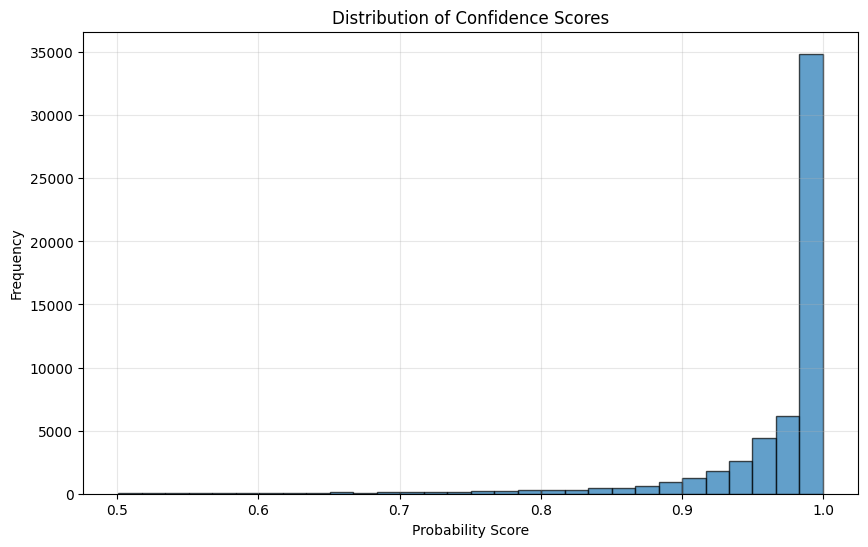

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic histogram
plt.figure(figsize=(10, 6))
plt.hist(dx['prob'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Distribution of Confidence Scores')
plt.xlabel('Probability Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import pandas as pd

dx = pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage2/instructor/sdev2_test1/gpt-4o-mini")

dx

,id,url1,title,text,prob,questions,context,search_terms,request_tokens,response_tokens,total_tokens,time_taken
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999899,[What is the file size of the document 'Chiu_W...,[Chiu_Wiegand_CCMC_Me..>\n\n2017-04-14 18:58\n...,"[Chiu Wiegand CCMC presentation, Justin Boblit...",1883,342,2225,8.126258
1,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999899,[What is the name of the presentation by Poedt...,[01_Poedts-VSWMC stat..>\n\n2022-06-10 04:39\n...,"[2022 workshop presentations, June 10, 2022 pr...",1925,103,2028,3.033527
2,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2018/03_Wednesd...,Index of /publicData/workshops/2018/03_Wednesd...,0.999898,[What is the file size of the document titled ...,[3c.EricSuttonCCMC_me..>\n\n2018-05-02 19:43\n...,"[2018 workshop presentations, file sizes of wo...",1786,484,2270,10.676920
3,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2016/5_Friday_AM,Index of /publicData/workshops/2016/5_Friday_A...,0.999898,[What are the file sizes of the presentations ...,[Index of /publicData/workshops/2016/5_Friday_...,"[April 20, 2016 workshop presentations, file s...",1885,319,2204,7.148071
4,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon/,Index of /publicData/kameleon,Index of /publicData/kameleon\n\nIndex of /pub...,0.999898,[What is the file size of the CORHEL_MAS.tar.b...,[CORHEL_MAS.tar.bz2\n\n2022-08-05 15:15\n\n83M...,"[CORHEL_MAS.tar.bz2 file size, ENLIL.tar.bz2 l...",1734,311,2045,7.223038
...,...,...,...,...,...,...,...,...,...,...,...,...
95,/SDE/coordinated_data_analysis_web_cdaweb/|htt...,https://cdaweb.gsfc.nasa.gov/WebServices/REST/...,Directory: ./ (CDAS R1.8.2 Web Services API),Directory: ./ (CDAS R1.8.17 Web Services API)\...,0.999821,[What does the spdfcdas class represent in the...,[spdfcdas__define.pro\n\nThis class represents...,"[Coordinated Data Analysis System API, NASA Sp...",2626,926,3552,22.280026
96,/SDE/2mass_2_micron_all_sky_survey/|https://ww...,https://www.ipac.caltech.edu/2mass/gallery/sho...,2MASS Showcase: Maffei 1&2,2MASS Showcase: Maffei 1&2\n\nMaffei 1&2\n\nIm...,0.999819,"[What are Maffei 1 and Maffei 2?, What is the ...",[Maffei 1 and Maffei 2 are large galaxies that...,"[Maffei 1 galaxy, Maffei 2 galaxy, 2MASS Showc...",1517,246,1763,6.700796
97,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/wsa-dashboard/forec...,WSA Dashboard,WSA Dashboard\n\nWSA Dashboard\n\nForecast Foo...,0.999804,[What is the function of the WSA Dashboard in ...,[The WSA Dashboard provides information on the...,"[WSA Dashboard forecast footpoints, WSA Dashbo...",1646,507,2153,12.572835
98,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon...,open_ggcm.tar.bz2,open_ggcm.tar.bz2\n\nopen_ggcm.tar.bz2 ‮⁤‭\n\n...,0.999792,[What is the significance of the open_ggcm.tar...,[The open_ggcm.tar.bz2 file is a compressed ar...,"[Open GGCM software, open_ggcm.tar.bz2 archive...",1460,398,1858,10.105509


In [ ]:
# let looks at average response_tokens
dx["response_tokens"].describe()

# lets say in average 500 tokens are used as response tokens

count     100.000000
mean      428.760000
std       249.423664
min        79.000000
25%       253.750000
50%       387.500000
75%       565.750000
max      1447.000000
Name: response_tokens, dtype: float64

In [4]:
import tiktoken

# Use the encoding for gpt-4o-mini and gpt-4o
encoding = tiktoken.get_encoding("o200k_base")

# Define function to count tokens
def count_tokens(text):
    """Count tokens in text using tiktoken"""
    if pd.isna(text) or text == "":
        return 0
    tokens = encoding.encode(str(text))
    return len(tokens)

# Apply the function to create new column
dx['n_tokens_text'] = dx['text'].apply(count_tokens)

# Show results
print(f"Added 'n_tokens_text' column")
print(f"Token count range: {dx['n_tokens_text'].min()} - {dx['n_tokens_text'].max()}")
print(f"Mean tokens per text: {dx['n_tokens_text'].mean():.1f}")

# Show some examples
print("\nSample results:")
print(dx[['title', 'n_tokens_text']].head())

# Show distribution stats
print(f"\nToken count statistics:")
print(dx['n_tokens_text'].describe())

Added 'n_tokens_text' column
Token count range: 310 - 501
Mean tokens per text: 418.6

Sample results:
                                               title  n_tokens_text
0  Index of /publicData/workshops/ICCMC-LWS-2017/...            459
1  Index of /publicData/workshops/2022/presentati...            501
2  Index of /publicData/workshops/2018/03_Wednesd...            362
3    Index of /publicData/workshops/2016/5_Friday_AM            461
4                      Index of /publicData/kameleon            310

Token count statistics:
count      5.000000
mean     418.600000
std       79.399622
min      310.000000
25%      362.000000
50%      459.000000
75%      461.000000
max      501.000000
Name: n_tokens_text, dtype: float64


In [8]:
dx

,id,url1,title,text,prob,questions,context,search_terms,request_tokens,response_tokens,total_tokens,time_taken,n_tokens_text
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999899,[What is the file size of Jon Vandegriff's dis...,[Jon_Vandegriff_getti..>\n\n2017-04-14 18:58\n...,"[ICCMC LWS 2017 workshop discussions, Jon Vand...",1883,826,2709,17.253744,459
1,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999899,[What is the size of the presentation file tit...,[04_DeDonder_NewSPENV..>\n\n2022-06-09 08:18\n...,"[PITHIA-N presentation by Belehaki, 2022 works...",1925,597,2522,13.417350,501
2,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2018/03_Wednesd...,Index of /publicData/workshops/2018/03_Wednesd...,0.999898,[What file contains information about satellit...,[3b.propagators.pdf is a file related to satel...,"[satellite propagators workshop 2018, CCMC dat...",1786,515,2301,9.316341,362
3,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2016/5_Friday_AM,Index of /publicData/workshops/2016/5_Friday_A...,0.999898,[What is the size of the file named 1_Dibyendu...,[Name Last modified Size Description Parent Di...,"[Friday AM workshop 2016 files, size of 1_Diby...",1885,820,2705,14.374358,461
4,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon/,Index of /publicData/kameleon,Index of /publicData/kameleon\n\nIndex of /pub...,0.999898,[What are the files available in the publicDat...,[Index of /publicData/kameleon\n\nName\n\nLast...,"[publicData Kameleon directory files, CORHEL_M...",1734,396,2130,9.152584,310


In [9]:
dx["n_prompt_tokens"] = dx["request_tokens"] - dx["n_tokens_text"]

In [10]:
dx

,id,url1,title,text,prob,questions,context,search_terms,request_tokens,response_tokens,total_tokens,time_taken,n_tokens_text,n_prompt_tokens
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999899,[What is the file size of Jon Vandegriff's dis...,[Jon_Vandegriff_getti..>\n\n2017-04-14 18:58\n...,"[ICCMC LWS 2017 workshop discussions, Jon Vand...",1883,826,2709,17.253744,459,1424
1,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999899,[What is the size of the presentation file tit...,[04_DeDonder_NewSPENV..>\n\n2022-06-09 08:18\n...,"[PITHIA-N presentation by Belehaki, 2022 works...",1925,597,2522,13.417350,501,1424
2,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2018/03_Wednesd...,Index of /publicData/workshops/2018/03_Wednesd...,0.999898,[What file contains information about satellit...,[3b.propagators.pdf is a file related to satel...,"[satellite propagators workshop 2018, CCMC dat...",1786,515,2301,9.316341,362,1424
3,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2016/5_Friday_AM,Index of /publicData/workshops/2016/5_Friday_A...,0.999898,[What is the size of the file named 1_Dibyendu...,[Name Last modified Size Description Parent Di...,"[Friday AM workshop 2016 files, size of 1_Diby...",1885,820,2705,14.374358,461,1424
4,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon/,Index of /publicData/kameleon,Index of /publicData/kameleon\n\nIndex of /pub...,0.999898,[What are the files available in the publicDat...,[Index of /publicData/kameleon\n\nName\n\nLast...,"[publicData Kameleon directory files, CORHEL_M...",1734,396,2130,9.152584,310,1424


In [11]:
# we realised n_prompt_tokens = 1424

In [12]:
df_oss = pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage2/instructor/sdev2_test1/gpt-oss:20b")

In [13]:
df_oss

,id,url1,title,text,prob,questions,context,search_terms,request_tokens,response_tokens,total_tokens,time_taken
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999899,[],[],[],None,None,None,None


In [18]:
original_df = pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/data/sde_new_dump/filtered_sde_20251024_dump_with_prob.parquet")

In [21]:
original_df = original_df.head(56316//10)

In [22]:
import tiktoken

# Use the encoding for gpt-4o-mini and gpt-4o
encoding = tiktoken.get_encoding("o200k_base")

# Define function to count tokens
def count_tokens(text):
    """Count tokens in text using tiktoken"""
    if pd.isna(text) or text == "":
        return 0
    tokens = encoding.encode(str(text))
    return len(tokens)

# Apply the function to create new column
original_df['n_tokens_text'] = original_df['text'].apply(count_tokens)

# Show results
print(f"Added 'n_tokens_text' column")
print(f"Token count range: {original_df['n_tokens_text'].min()} - {original_df['n_tokens_text'].max()}")
print(f"Mean tokens per text: {original_df['n_tokens_text'].mean():.1f}")

# Show some examples
print("\nSample results:")
print(original_df[['title', 'n_tokens_text']].head())

# Show distribution stats
print(f"\nToken count statistics:")
print(original_df['n_tokens_text'].describe())

Added 'n_tokens_text' column
Token count range: 25 - 764286
Mean tokens per text: 3366.4

Sample results:
                                               title  n_tokens_text
0  Index of /publicData/workshops/ICCMC-LWS-2017/...            459
1  Index of /publicData/workshops/2022/presentati...            501
2  Index of /publicData/workshops/2018/03_Wednesd...            362
3    Index of /publicData/workshops/2016/5_Friday_AM            461
4                      Index of /publicData/kameleon            310

Token count statistics:
count      5631.000000
mean       3366.365832
std       40197.278124
min          25.000000
25%         571.000000
50%         788.000000
75%        1048.000000
max      764286.000000
Name: n_tokens_text, dtype: float64


In [23]:
original_df.head()

,id,url1,title,collection,treepath,sourcestr56,text,sourcebool3,prob,n_tokens_text
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,/SDE/CCMC_Website/,/Heliophysics/Community Coordinated Modeling C...,Data,Index of /publicData/workshops/ICCMC-LWS-2017/...,False,0.999899,459
1,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,/SDE/CCMC_Website/,/Heliophysics/Community Coordinated Modeling C...,Data,Index of /publicData/workshops/2022/presentati...,False,0.999899,501
2,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2018/03_Wednesd...,/SDE/CCMC_Website/,/Heliophysics/Community Coordinated Modeling C...,Data,Index of /publicData/workshops/2018/03_Wednesd...,False,0.999898,362
3,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2016/5_Friday_AM,/SDE/CCMC_Website/,/Heliophysics/Community Coordinated Modeling C...,Data,Index of /publicData/workshops/2016/5_Friday_A...,False,0.999898,461
4,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon/,Index of /publicData/kameleon,/SDE/CCMC_Website/,/Heliophysics/Community Coordinated Modeling C...,Data,Index of /publicData/kameleon\n\nIndex of /pub...,False,0.999898,310


In [24]:
original_df["n_input_response_tokens"] = 1424 + original_df["n_tokens_text"]

In [25]:
original_df["n_input_response_tokens"].sum()

np.int64(26974550)

In [26]:
input_cost = (0.15 / 1_000_000) * 26974550
input_cost

4.0461825

In [27]:
original_df.shape

(5631, 11)

In [29]:
# output cost
output_cost = (0.60 / 1_000_000) *  (500 * 5631)
output_cost

1.6893

In [30]:
1.6893 + 4.0461825

5.7354825

In [1]:
import pandas as pd

df = pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage2/instructor/sdev2_test1/gpt-4o-mini")

In [2]:
df

,id,url1,title,text,prob,questions,context,search_terms,request_tokens,response_tokens,total_tokens,time_taken
0,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/ICCMC-LWS-2017/...,Index of /publicData/workshops/ICCMC-LWS-2017/...,0.999899,[What is the file size of the document 'Chiu_W...,[Chiu_Wiegand_CCMC_Me..>\n\n2017-04-14 18:58\n...,"[Chiu Wiegand CCMC presentation, Justin Boblit...",1883.0,342.0,2225.0,8.126258
1,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2022/presentati...,Index of /publicData/workshops/2022/presentati...,0.999899,[What is the name of the presentation by Poedt...,[01_Poedts-VSWMC stat..>\n\n2022-06-10 04:39\n...,"[2022 workshop presentations, June 10, 2022 pr...",1925.0,103.0,2028.0,3.033527
2,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2018/03_Wednesd...,Index of /publicData/workshops/2018/03_Wednesd...,0.999898,[What is the file size of the document titled ...,[3c.EricSuttonCCMC_me..>\n\n2018-05-02 19:43\n...,"[2018 workshop presentations, file sizes of wo...",1786.0,484.0,2270.0,10.676920
3,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/workshop...,Index of /publicData/workshops/2016/5_Friday_AM,Index of /publicData/workshops/2016/5_Friday_A...,0.999898,[What are the file sizes of the presentations ...,[Index of /publicData/workshops/2016/5_Friday_...,"[April 20, 2016 workshop presentations, file s...",1885.0,319.0,2204.0,7.148071
4,/SDE/CCMC_Website/|https://ccmc.gsfc.nasa.gov/...,https://ccmc.gsfc.nasa.gov/publicData/kameleon/,Index of /publicData/kameleon,Index of /publicData/kameleon\n\nIndex of /pub...,0.999898,[What is the file size of the CORHEL_MAS.tar.b...,[CORHEL_MAS.tar.bz2\n\n2022-08-05 15:15\n\n83M...,"[CORHEL_MAS.tar.bz2 file size, ENLIL.tar.bz2 l...",1734.0,311.0,2045.0,7.223038
...,...,...,...,...,...,...,...,...,...,...,...,...
5626,/SDE/airs_atmospheric_infrared_sounder/|https:...,https://airs.jpl.nasa.gov/news/192/airs-captur...,AIRS Captures Extreme Cold Air Outbreak Sweepi...,AIRS Captures Extreme Cold Air Outbreak Sweepi...,0.999033,[What observations did the AIRS instrument cap...,[As a winter storm and severe cold sweeps acro...,[AIRS extreme cold air outbreak North America ...,3607.0,796.0,4403.0,15.327628
5627,/SDE/lambda_legacy_archive_for_microwave_backg...,https://lambda.gsfc.nasa.gov/product/wmap/dr4/...,LAMBDA - WMAP Cosmological Parameters<br>Model...,LAMBDA - WMAP Cosmological Parameters Model: l...,0.999033,[What cosmological parameters are included in ...,[LAMBDA - WMAP Cosmological Parameters Model: ...,"[LAMBDA WMAP Cosmological Parameters Model, lc...",1924.0,515.0,2439.0,10.421807
5628,/SDE/earth_science_division_publications/|http...,https://esdpubs.nasa.gov/content/Additivity_of...,Additivity of integral optical cross sections ...,Additivity of integral optical cross sections ...,0.999033,[What is demonstrated regarding the additivity...,[We use the volume integral equation formulati...,"[Mishchenko Yurkin optical cross sections, add...",1854.0,472.0,2326.0,9.530748
5629,/SDE/earth_science_division_publications/|http...,https://esdpubs.nasa.gov/content/Validation_an...,Validation and error estimation of AIRS MUSES ...,Validation and error estimation of AIRS MUSES ...,0.999033,[What retrieval approach is used for evaluatin...,[The retrievals are obtained using an optimal ...,"[AIRS MUSES CO profile validation, HIPPO aircr...",2351.0,785.0,3136.0,14.858417
